Bivariate ANM, prototype. Companion to the proposal.

Reference recipe is Hoyer et al. (2009); pHSIC variant from Mooij et al. (2016, Tab. 1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prototype_anm import ANM, hsic, sim_anm, sim_linear_gaussian

In [2]:
pair = sim_anm(n=500, seed=0)
m = ANM(random_state=0).fit(pair)

m.direction_, m.s_fwd_, m.s_bwd_, m.confidence_

(('x', 'y'), 0.0006365339441194892, 0.0014745393279073492, 0.39695703360560874)

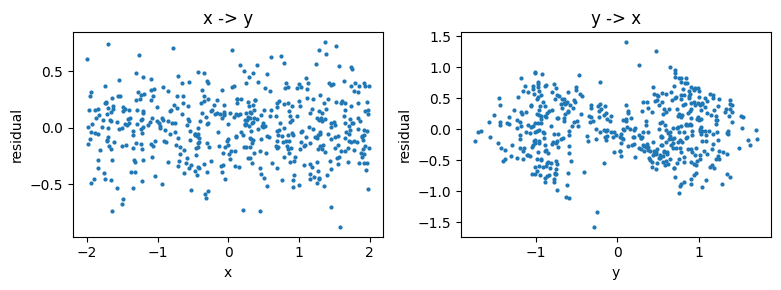

In [3]:
# residuals in the correct direction should be independent of x;
# residuals in the reverse direction should not.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

x, y = pair["x"].to_numpy(), pair["y"].to_numpy()
gp_fwd = GaussianProcessRegressor(kernel=RBF()+WhiteKernel(), normalize_y=True).fit(x.reshape(-1,1), y)
gp_bwd = GaussianProcessRegressor(kernel=RBF()+WhiteKernel(), normalize_y=True).fit(y.reshape(-1,1), x)
r_fwd = y - gp_fwd.predict(x.reshape(-1,1))
r_bwd = x - gp_bwd.predict(y.reshape(-1,1))

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].scatter(x, r_fwd, s=4); ax[0].set(xlabel="x", ylabel="residual", title="x -> y")
ax[1].scatter(y, r_bwd, s=4); ax[1].set(xlabel="y", ylabel="residual", title="y -> x")
plt.tight_layout()

In [4]:
# Recovery rate over 50 seeds, n = 500.
import time
t0 = time.time()

hits = sum(
    ANM(random_state=s).fit(sim_anm(500, s)).direction_ == ("x", "y")
    for s in range(50)
)
print(hits, "/ 50", "in", round(time.time()-t0, 1), "s")

49 / 50 in 7.1 s


In [5]:
# Identifiability counterexample: linear Gaussian (Peters 14, Thm 1).
# Direction may flip seed-to-seed; confidence collapses.
for s in range(5):
    m = ANM(random_state=s).fit(sim_linear_gaussian(500, s))
    print(m.direction_, "  conf =", round(m.confidence_, 3))

('x', 'y')   conf = 0.09
('x', 'y')   conf = 0.2
('y', 'x')   conf = 0.063
('y', 'x')   conf = 0.113
('x', 'y')   conf = 0.011
